# Research agent: a four-way head-to-head

**The brief**
> "For these 10 tickers, find the most recent quarterly earnings,
> flag whether EPS beat consensus, and write a one-paragraph cohort
> summary. Stay under $2."

**The contest**

| | Version A | Version B | Version C |
|---|---|---|---|
| Shape | `create_react_agent(llm, tools)` | hand-wired `StateGraph` | LangGOAP `GoapGraph` |
| LoC | ~150 | ~170 | ~205 |
| Control flow | LLM decides every turn | dev-decided per node | A* planner over `ActionSpec`s |
| Failure recovery | None unless you write it | None unless you write it | Free, from the action graph |

Same brief, same five tools, same model (`gpt-4o-mini`), real Tavily, real
OpenAI charges. We measure dollars, tokens, and recovery behaviour
under a Tavily-key revocation.

In [1]:
# Setup: load API keys, import the four agent modules.
# `.env` is loaded by `examples.screencast.research_agent.shared` on
# import — see `shared/__init__.py`. We just verify the keys arrived.
import os

import matplotlib.pyplot as plt
import numpy as np

from examples.screencast.research_agent import (
    disrupted as disrupted_mod,
    langgoap_planned,
    langgraph_routed,
    react_baseline,
)
from examples.screencast.research_agent.shared import TICKERS, RunResult

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY missing (set in .env)"
assert os.environ.get("TAVILY_API_KEY"), "TAVILY_API_KEY missing (set in .env)"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_REACT = "#5b6770"
COLOR_ROUTED = "#5b6770"
COLOR_GOAP = "#2a9d8f"
COLOR_FAIL = "#c0392b"


def show(r: RunResult) -> None:
    cs = r.cost_summary
    print(
        f"  status:    {r.status}\n"
        f"  cost:      ${cs['total_cost_usd']:.4f}    "
        f"tokens: {cs['total_tokens']:,}    "
        f"LLM calls: {cs['llm_call_count']}\n"
        f"  Tavily:    {cs['tavily_call_count']}        "
        f"DDG:    {cs['ddg_call_count']}        "
        f"wall:  {r.elapsed_s:.1f}s"
    )
    if r.path_taken:
        print(f"  path:      {' → '.join(r.path_taken)}")
    if r.error:
        print(f"  error:     {r.error}")


print(f"Cohort: {len(TICKERS)} tickers — {', '.join(TICKERS)}")

Cohort: 10 tickers — AAPL, MSFT, GOOG, AMZN, META, NVDA, TSLA, JPM, WMT, NFLX


## Slide · Version A: the `create_react_agent` baseline

```python
agent = create_react_agent(llm, [tavily_search, duckduckgo_search,
                                 extract_earnings, compare_to_consensus,
                                 synthesize_summary])
agent.invoke({"messages": [SystemMessage(...), HumanMessage(brief)]})
```

One line of agent code. The LLM picks the next tool every turn. This
is the canonical comparison floor.

In [2]:
print("Version A — create_react_agent baseline ...")
result_react = react_baseline.run()
show(result_react)

Version A — create_react_agent baseline ...


  status:    ok
  cost:      $0.0846    tokens: 21,281    LLM calls: 26
  Tavily:    10        DDG:    0        wall:  57.2s


## Slide · Version B: hand-wired LangGraph

```python
builder = StateGraph(GraphState)
builder.add_node("search", ...)    # calls tavily_search directly
builder.add_node("extract", ...)
builder.add_node("compare", ...)
builder.add_node("synthesize", ...)
builder.add_conditional_edges("compare", route, {...})
```

Explicit nodes, deterministic order, no LLM in the dispatcher loop.
What a senior LangGraph dev reaches for after react proves unpredictable.
**Intentional weakness:** no fallback edge from `search` — the dev
decided that was overkill on Friday.

In [3]:
print("Version B — hand-wired LangGraph StateGraph ...")
result_routed = langgraph_routed.run()
show(result_routed)

Version B — hand-wired LangGraph StateGraph ...


  status:    ok
  cost:      $0.0810    tokens: 4,257    LLM calls: 21
  Tavily:    10        DDG:    0        wall:  41.1s


## Slide · Version C: LangGOAP planned

Declare each tool as an `ActionSpec` with a USD cost estimate; put
the budget on the goal.

```python
ActionSpec(
    name="search_all_via_tavily",
    preconditions={"raw_snippets": False},
    effects={"raw_snippets": True},
    cost=1.0,                                    # A* weight
    resources={"cost_usd": 0.085},               # CSP cap
    fn=lambda ws: tavily_search_all(ws["tickers"]),
)

# DuckDuckGo is the same effect, A* cost=3.0 (second choice)
ActionSpec(name="search_all_via_ddg", cost=3.0, resources={"cost_usd": 0.0}, ...)

GoalSpec(
    conditions={"summary_ready": True},
    constraints=(ConstraintSpec(key="cost_usd", max=2.00, level="hard"),),
    policy=GoalPolicy(replan_strategy=ReplanStrategy.ON_DEVIATION, max_replans=3),
)
```

The planner picks Tavily on the happy path (lower A* cost). The
$2.00 cap lives on the goal, not in a retry callback.

In [4]:
print("Version C — LangGOAP with cost-aware ActionSpecs ...")
result_goap = langgoap_planned.run()
show(result_goap)

Version C — LangGOAP with cost-aware ActionSpecs ...


  status:    goal_achieved
  cost:      $0.0809    tokens: 4,211    LLM calls: 21
  Tavily:    10        DDG:    0        wall:  39.2s
  path:      search_all_via_tavily → extract_all_earnings → compare_all_to_consensus → synthesize_summary


## Slide · Happy path — the three-bar reveal

All three finish. The dollar totals land within a rounding error because
Tavily call costs (10 paid searches) dominate the bill.

**The quieter story is in the token meter:** react re-derives the plan
on every turn, so it burns roughly **4.7×** the LLM tokens of the other
two for the same work. On `gpt-4o-mini` that's noise; on `gpt-4` or
`claude-opus` it isn't.

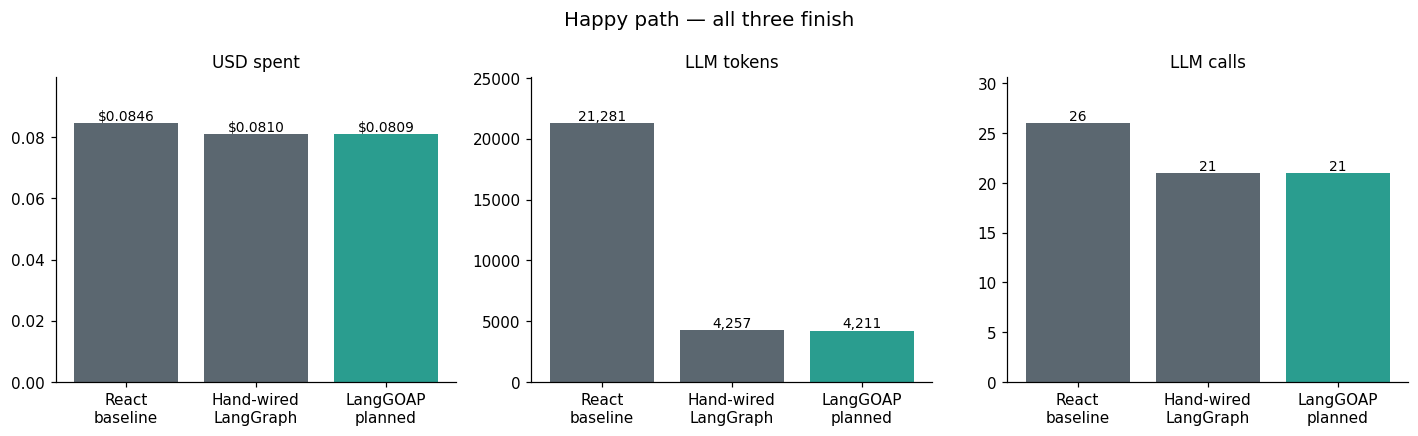

In [5]:
happy = [result_react, result_routed, result_goap]
labels = ["React\nbaseline", "Hand-wired\nLangGraph", "LangGOAP\nplanned"]
colors = [COLOR_REACT, COLOR_ROUTED, COLOR_GOAP]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [
    ("total_cost_usd", "USD spent",   "${:.4f}"),
    ("total_tokens",   "LLM tokens",  "{:,}"),
    ("llm_call_count", "LLM calls",   "{}"),
]
for ax, (key, title, fmt) in zip(axes, metrics):
    values = [r.cost_summary[key] for r in happy]
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(top=max(values) * 1.18 if max(values) else 1)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                fmt.format(v), ha="center", va="bottom", fontsize=9)
fig.suptitle("Happy path — all three finish", fontsize=13)
fig.tight_layout()
plt.show()

## Slide · *...until Monday.*

The bars look the same. The viewer is unconvinced. *"Why bother with a
planner if my hand-wired graph costs the same?"*

Then Tavily rotates its API keys overnight.

## Slide · The disruption

We pop `TAVILY_API_KEY` from the environment and rerun all three.
**No code changes. No retry logic.**

`disrupted.run()` is a context manager that unsets the key for the
duration of the runs and restores it afterward. The crashes you're
about to see are real, not mocked.

In [6]:
print("Disruption: revoking TAVILY_API_KEY for all three runs ...\n")
disrupted_results = disrupted_mod.run()

Disruption: revoking TAVILY_API_KEY for all three runs ...


  DISRUPTION: TAVILY_API_KEY revoked

--- Version A: react_baseline ---


Action 'search_all_via_tavily' failed: TAVILY_API_KEY missing or revoked


  status=error          cost=$0.0002  tokens=511  tavily=0  ddg=0  replans=0  wall=3.3s
  error: TavilyUnauthorized: TAVILY_API_KEY missing or revoked

--- Version B: langgraph_routed ---
  status=error          cost=$0.0000  tokens=0  tavily=0  ddg=0  replans=0  wall=0.0s
  error: TavilyUnauthorized: TAVILY_API_KEY missing or revoked

--- Version C: langgoap_planned ---


  status=goal_achieved  cost=$0.0009  tokens=4,074  tavily=0  ddg=10  replans=1  wall=39.8s

  Side-by-side
  version                status             cost  replans
  ---------------------- -------------- -------- --------
  react_baseline         error           0.0002$        0
  langgraph_routed       error           0.0000$        0
  langgoap_planned       goal_achieved   0.0009$        1


## Slide · The bar chart that sells the framework

Three bars on the left — happy path. Three bars on the right — same
agents, one revoked key. Red = the run produced no usable summary.

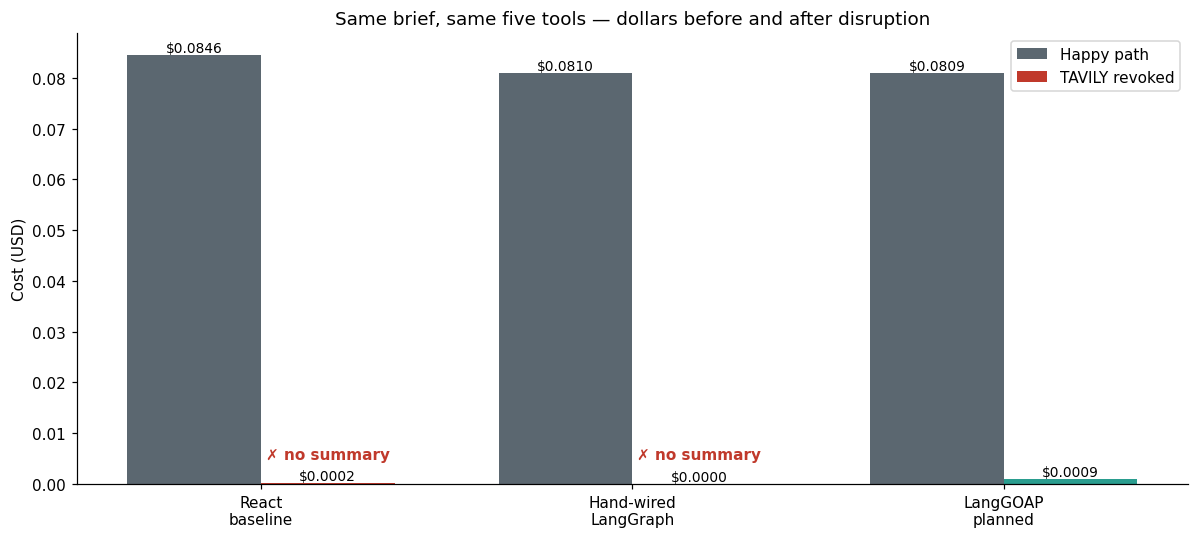

In [7]:
x_labels = ["React\nbaseline", "Hand-wired\nLangGraph", "LangGOAP\nplanned"]
happy_costs = [r.cost_summary["total_cost_usd"] for r in happy]
dis_costs = [r.cost_summary["total_cost_usd"] for r in disrupted_results]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(x_labels))
w = 0.36
bars_h = ax.bar(x - w / 2, happy_costs, w, label="Happy path", color=COLOR_REACT)
dis_colors = [
    COLOR_FAIL if r.status != "goal_achieved" else COLOR_GOAP
    for r in disrupted_results
]
bars_d = ax.bar(x + w / 2, dis_costs, w, label="TAVILY revoked", color=dis_colors)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Cost (USD)")
ax.set_title("Same brief, same five tools — dollars before and after disruption")
ax.legend(loc="upper right")

for bars in (bars_h, bars_d):
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, v, f"${v:.4f}",
                ha="center", va="bottom", fontsize=9)

for i, r in enumerate(disrupted_results):
    if r.status != "goal_achieved":
        ax.annotate("✗ no summary", xy=(i + w / 2, dis_costs[i]),
                    xytext=(0, 16), textcoords="offset points",
                    ha="center", color=COLOR_FAIL, fontweight="bold")
plt.tight_layout()
plt.show()

## Slide · The receipt

Same five tools. Same brief. Three agents, one survives the
disruption — and it's the one where we declared *what was possible*
(actions, preconditions, effects, costs) instead of *what to do when*
(an edge per failure mode).

The recovery wasn't coded. **It emerged from the planner being asked
to satisfy the goal with whatever actions remained feasible.**

In [8]:
def row(r: RunResult, scenario: str) -> str:
    cs = r.cost_summary
    return (
        f"| {scenario:<12} | {r.name:<22} | {r.status:<14} | "
        f"${cs['total_cost_usd']:.4f} | {cs['total_tokens']:>6,} | "
        f"{cs['tavily_call_count']:>3} | {cs['ddg_call_count']:>3} | "
        f"{r.replans:>3} | {r.elapsed_s:>5.1f}s |"
    )

print("| scenario     | version                | status         | cost    | tokens | tav | ddg | rep | wall   |")
print("|--------------|------------------------|----------------|---------|--------|-----|-----|-----|--------|")
for r in happy:
    print(row(r, "happy"))
for r in disrupted_results:
    print(row(r, "disrupted"))

| scenario     | version                | status         | cost    | tokens | tav | ddg | rep | wall   |
|--------------|------------------------|----------------|---------|--------|-----|-----|-----|--------|
| happy        | react_baseline         | ok             | $0.0846 | 21,281 |  10 |   0 |   0 |  57.2s |
| happy        | langgraph_routed       | ok             | $0.0810 |  4,257 |  10 |   0 |   0 |  41.1s |
| happy        | langgoap_planned       | goal_achieved  | $0.0809 |  4,211 |  10 |   0 |   0 |  39.2s |
| disrupted    | react_baseline         | error          | $0.0002 |    511 |   0 |   0 |   0 |   3.3s |
| disrupted    | langgraph_routed       | error          | $0.0000 |      0 |   0 |   0 |   0 |   0.0s |
| disrupted    | langgoap_planned       | goal_achieved  | $0.0009 |  4,074 |   0 |  10 |   1 |  39.8s |


## Slide · Takeaways

1. **On the happy path, the three agents look the same** at the dollar
   level (Tavily dominates the bill). The token meter reveals that
   react spends ~4.7× the LLM thinking on the same workload.
2. **Under one revoked credential the picture diverges hard.** The
   react baseline raises out of `agent.invoke()`; the hand-wired graph
   errors before the first LLM call. The planner blacklists the
   failing action and replans through DuckDuckGo without any new
   edges, new nodes, or new state fields.
3. **The cost cap lives on the goal**, not in a retry callback or
   middleware. `ConstraintSpec(key="cost_usd", max=2.00)` is enforced
   by the planner before each action commits.

### What this notebook deliberately does *not* claim

- LangGOAP isn't faster than react on the happy path. It runs at
  LLM/tool latency; the A* overhead is sub-millisecond.
- LangGOAP doesn't write recovery edges *for* you. It uses the
  actions you declared. If you only declare Tavily, it cannot replan
  through DuckDuckGo — *you have to give it the option*.

When you give the planner options, it uses them under failure. The
hand-wired graph can't, without new edges.

## Slide · Next steps

- **Read** the matching narrative —
  [`narrative.md`](narrative.md) walks through the same numbers in prose.
- **Watch** the 7-minute recording shot-list —
  [`script.md`](script.md) has timecodes for every cut in this notebook.
- **Browse** the cost-bounded tutorial —
  [`../tutorials/cost_bounded_research_agent.ipynb`](../../tutorials/cost_bounded_research_agent.ipynb)
  unpacks the termination-policy and wall-clock cap surface that this
  notebook only sketches.
- **Star** the repo and open an issue with the scenario you'd like to
  see next — [github.com/integrallis/langgoap](https://github.com/integrallis/langgoap).